In [6]:
### Import necessary packages ..

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1.. reading data from Sqlite database

In [8]:
import sqlite3

In [9]:
# Create a SQL connection to our SQLite database
con = sqlite3.connect(r'F:\Python Practice\Data Analyst Project\Developed Projects\Amazon Customers Data Analysis\\database.sqlite')

In [10]:
type(con)

sqlite3.Connection

#### reading data from Sqlite database

In [11]:
df = pd.read_sql_query("SELECT * FROM REVIEWS" , con)

In [12]:
df.shape ## checking dimensions of df dataframe ..

(568454, 10)

## 2.. Data Preparation !
    Doing basic cleaning/Data wrangling(remove invalid rows , remove duplicate rows ..) & convert "time" feature data-type 
    to date-time

In [13]:
type(df) ## ie df is a dataframe

pandas.core.frame.DataFrame

In [14]:
df.head(4)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...


In [15]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [16]:
df['HelpfulnessNumerator'] > df['HelpfulnessDenominator'] 

0         False
1         False
2         False
3         False
4         False
          ...  
568449    False
568450    False
568451    False
568452    False
568453    False
Length: 568454, dtype: bool

In [17]:
df[df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']]   ## invalid rows

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
44736,44737,B001EQ55RW,A2V0I904FH7ABY,Ram,3,2,4,1212883200,Pure cocoa taste with crunchy almonds inside,It was almost a 'love at first bite' - the per...
64421,64422,B000MIDROQ,A161DK06JJMCYF,"J. E. Stephens ""Jeanne""",3,1,5,1224892800,Bought This for My Son at College,My son loves spaghetti so I didn't hesitate or...


In [18]:
df_valid = df[df['HelpfulnessNumerator'] <= df['HelpfulnessDenominator']]  ## valid rows 

In [19]:
df_valid.shape

(568452, 10)

### lets find out whether instances/rows are duplicate or not !


    Deduplication means removing duplicate rows, It is necessary to remove duplicates in order to get unbaised results,
    
    Checking duplicates based on UserId, ProfileName, Time, Text as No user can type a review on same exact time for 
    different products, so we will remove those records

In [20]:
df_valid.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [21]:
df_valid.duplicated(['UserId', 'ProfileName' ,'Time' ,'Text'])

0         False
1         False
2         False
3         False
4         False
          ...  
568449    False
568450    False
568451    False
568452    False
568453    False
Length: 568452, dtype: bool

In [22]:
df_valid[df_valid.duplicated(['UserId', 'ProfileName' ,'Time' ,'Text'])]

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
29,30,B0001PB9FY,A3HDKO7OW0QNK4,Canadian Fan,1,1,5,1107820800,The Best Hot Sauce in the World,I don't know if it's the cactus or the tequila...
574,575,B000G6RYNE,A3PJZ8TU8FDQ1K,Jared Castle,2,2,5,1231718400,"One bite and you'll become a ""chippoisseur""","I'm addicted to salty and tangy flavors, so wh..."
1973,1974,B0017165OG,A2EPNS38TTLZYN,tedebear,0,0,3,1312675200,Pok Chops,The pork chops from Omaha Steaks were very tas...
2309,2310,B0001VWE0M,AQM74O8Z4FMS0,Sunshine,0,0,2,1127606400,Below standard,Too much of the white pith on this orange peel...
2323,2324,B0001VWE0C,AQM74O8Z4FMS0,Sunshine,0,0,2,1127606400,Below standard,Too much of the white pith on this orange peel...
...,...,...,...,...,...,...,...,...,...,...
568409,568410,B0018CLWM4,A2PE0AGWV6OPL7,Dark Water Mermaid,3,3,5,1309651200,Quality & affordable food,I was very pleased with the ingredient quality...
568410,568411,B0018CLWM4,A88HLWDCU57WG,R28,2,2,5,1332979200,litter box,My main reason for the five star review has to...
568411,568412,B0018CLWM4,AUX1HSY8FX55S,DAW,1,1,5,1319500800,Happy Camper,I bought this to try on two registered Maine C...
568412,568413,B0018CLWM4,AVZ2OZ479Q9E8,Ai Ling Chow,0,0,5,1336435200,Two Siberians like it!,When we brought home two 3-month-old purebred ...


In [23]:
data = df_valid.drop_duplicates(subset=['UserId', 'ProfileName' ,'Time' ,'Text'])

In [24]:
data.shape

(393931, 10)

In [25]:
data.dtypes

Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

In [26]:
data['Time']

0         1303862400
1         1346976000
2         1219017600
3         1307923200
4         1350777600
             ...    
568449    1299628800
568450    1331251200
568451    1329782400
568452    1331596800
568453    1338422400
Name: Time, Length: 393931, dtype: int64

In [27]:
pd.to_datetime(data['Time'])

### as default is : unix start time "1970-01-01"

### 00:00:01.303862400 ->> by-default this time is in "nano-second" as default value of unit = "ns"
### so lets customize "unit" parameter to get time in second ..

0        1970-01-01 00:00:01.303862400
1        1970-01-01 00:00:01.346976000
2        1970-01-01 00:00:01.219017600
3        1970-01-01 00:00:01.307923200
4        1970-01-01 00:00:01.350777600
                      ...             
568449   1970-01-01 00:00:01.299628800
568450   1970-01-01 00:00:01.331251200
568451   1970-01-01 00:00:01.329782400
568452   1970-01-01 00:00:01.331596800
568453   1970-01-01 00:00:01.338422400
Name: Time, Length: 393931, dtype: datetime64[ns]

In [28]:
data['Time'] = pd.to_datetime(data['Time'] , unit='s')

C:\Users\Gaurav Kumar\AppData\Local\Temp\ipykernel_24508\2920101369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Time'] = pd.to_datetime(data['Time'] , unit='s')


In [29]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

## 3.. Analyse to what User Amazon Can recommend more product ? 

In [30]:
data.shape

(393931, 10)

In [31]:
data.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [32]:
data['ProfileName']

0                              delmartian
1                                  dll pa
2         Natalia Corres "Natalia Corres"
3                                    Karl
4           Michael D. Bigham "M. Wassir"
                       ...               
568449                   Lettie D. Carter
568450                          R. Sawyer
568451                      pksd "pk_007"
568452            Kathy A. Welch "katwel"
568453                           srfell17
Name: ProfileName, Length: 393931, dtype: object

In [33]:
data['ProfileName'].nunique()

### Total unique profile-name are 218418
## Note : Profile_Name could be same but User-ID will be different , so lets consider UserID for this analysis ..

218418

In [34]:
data['UserId'].nunique()

256059

In [35]:
recommened_df = data.groupby(['UserId']).agg({'Summary':'count','Text':'count','Score':'mean','ProductId':'count'}).sort_values(by='ProductId', ascending=False)

In [36]:
recommened_df

,Summary,Text,Score,ProductId
UserId,,,,
AY12DBB0U420B,329,329,4.659574,329
A3OXHLG6DIBRW8,278,278,4.546763,278
A281NPSIMI1C2R,259,259,4.787645,259
A1YUL9PCJR3JTY,214,214,4.621495,214
A1Z54EM24Y40LL,211,211,4.383886,211
...,...,...,...,...
A2E80MDB9TCNGW,1,1,3.000000,1
A2E80RT3HOR35T,1,1,5.000000,1
A2E816C5N51F6X,1,1,5.000000,1


In [37]:
recommened_df.index[0:10]

Index(['AY12DBB0U420B', 'A3OXHLG6DIBRW8', 'A281NPSIMI1C2R', 'A1YUL9PCJR3JTY',
       'A1Z54EM24Y40LL', 'A2MUGFV2TDQ47K', 'A3D6OI36USYOU1', 'AZV26LP92E6WU',
       'AKMEY1BSHSDG7', 'A2GEZJHBV92EVR'],
      dtype='object', name='UserId')

In [38]:
recommened_df['ProductId'][0:10].values

array([329, 278, 259, 214, 211, 161, 146, 129, 119, 118])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'AY12DBB0U420B'),
  Text(1, 0, 'A3OXHLG6DIBRW8'),
  Text(2, 0, 'A281NPSIMI1C2R'),
  Text(3, 0, 'A1YUL9PCJR3JTY'),
  Text(4, 0, 'A1Z54EM24Y40LL'),
  Text(5, 0, 'A2MUGFV2TDQ47K'),
  Text(6, 0, 'A3D6OI36USYOU1'),
  Text(7, 0, 'AZV26LP92E6WU'),
  Text(8, 0, 'AKMEY1BSHSDG7'),
  Text(9, 0, 'A2GEZJHBV92EVR')])

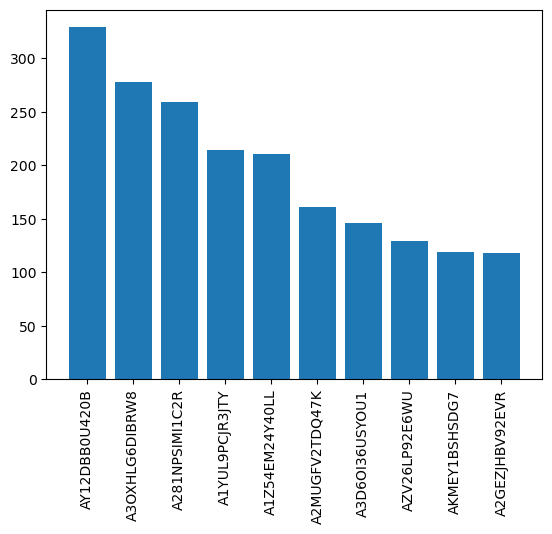

In [39]:
plt.bar(recommened_df.index[0:10],recommened_df['ProductId'][0:10].values)
plt.xticks(rotation='vertical')

In [40]:
 prod_count=data['ProductId'].value_counts().to_frame()


In [41]:
prod_count

,count
ProductId,
B007JFMH8M,912
B002QWP89S,630
B003B3OOPA,622
B001EO5Q64,566
B0013NUGDE,558
...,...
B002DNX4GO,1
B000FM2YU2,1
B001M1VA32,1


In [42]:
freq_prodID = prod_count[prod_count['count']>500].index

In [43]:
freq_prodID

Index(['B007JFMH8M', 'B002QWP89S', 'B003B3OOPA', 'B001EO5Q64', 'B0013NUGDE',
       'B000KV61FC', 'B000UBD88A', 'B000NMJWZO', 'B005K4Q37A', 'B0090X8IPM',
       'B005ZBZLT4'],
      dtype='object', name='ProductId')

In [44]:
data['ProductId'].isin(freq_prodID)

0         False
1         False
2         False
3         False
4         False
          ...  
568449    False
568450    False
568451    False
568452    False
568453    False
Name: ProductId, Length: 393931, dtype: bool

In [45]:
fre_prd = data[data['ProductId'].isin(freq_prodID)]

In [46]:
fre_prd.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

<Axes: xlabel='count', ylabel='ProductId'>

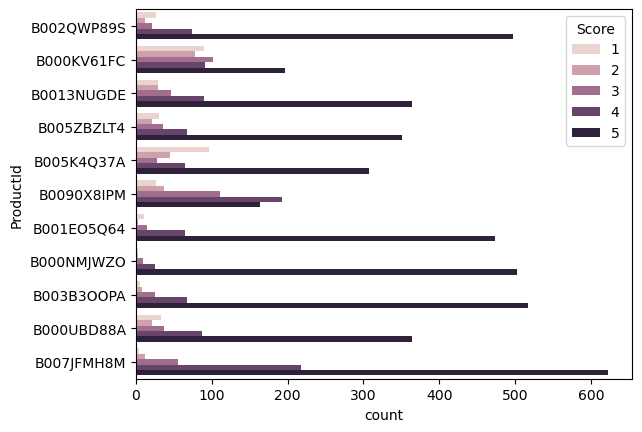

In [47]:
sns.countplot(y='ProductId', data = fre_prd, hue ='Score')

In [48]:
x = data['UserId'].value_counts()

In [49]:
data['Viwer_type'] = data['UserId'].apply(lambda  user : "Frequent" if x[user]>50 else "Not Frequent").sort_values()

In [50]:
data['Viwer_type'].unique()

array(['Not Frequent', 'Frequent'], dtype=object)

In [51]:
data['Viwer_type']=='Not Frequent'

0         True
1         True
2         True
3         True
4         True
          ... 
568449    True
568450    True
568451    True
568452    True
568453    True
Name: Viwer_type, Length: 393931, dtype: bool

In [52]:
nt_freq = not_freq_Df = data[data['Viwer_type']=='Not Frequent']
freq = not_freq_Df = data[data['Viwer_type']=='Frequent']

<Axes: xlabel='Score'>

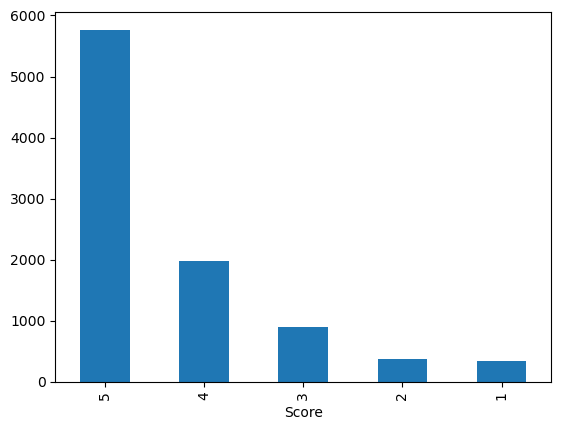

In [53]:
freq['Score'].value_counts().plot(kind = 'bar')

<Axes: xlabel='Score'>

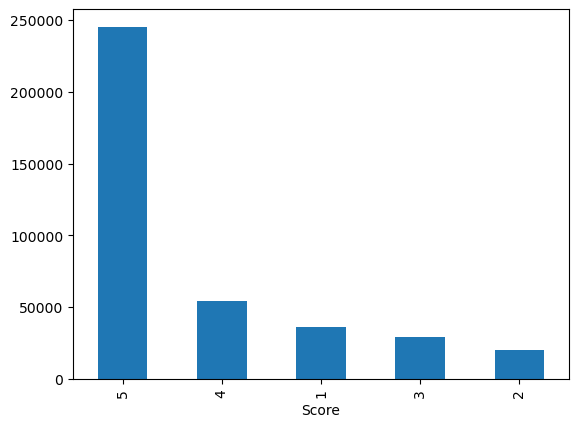

In [54]:
nt_freq['Score'].value_counts().plot(kind = 'bar')

In [55]:
data[['UserId','ProductId','Text']]

,UserId,ProductId,Text
0,A3SGXH7AUHU8GW,B001E4KFG0,I have bought several of the Vitality canned d...
1,A1D87F6ZCVE5NK,B00813GRG4,Product arrived labeled as Jumbo Salted Peanut...
2,ABXLMWJIXXAIN,B000LQOCH0,This is a confection that has been around a fe...
3,A395BORC6FGVXV,B000UA0QIQ,If you are looking for the secret ingredient i...
4,A1UQRSCLF8GW1T,B006K2ZZ7K,Great taffy at a great price. There was a wid...
...,...,...,...
568449,A28KG5XORO54AY,B001EO7N10,Great for sesame chicken..this is a good if no...
568450,A3I8AFVPEE8KI5,B003S1WTCU,I'm disappointed with the flavor. The chocolat...
568451,A121AA1GQV751Z,B004I613EE,"These stars are small, so you can give 10-15 o..."
568452,A3IBEVCTXKNOH,B004I613EE,These are the BEST treats for training and rew...


In [56]:
data['Text'][0]

'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [57]:
type(data['Text'][0].split())

list

In [58]:
len(data['Text'][0].split(' '))

49

In [59]:
def calculate_length(text):
    return len(text.split(' '))

In [60]:
data['Text_Length'] = data['Text'].apply(calculate_length)

In [61]:
nt_freq = not_freq_Df = data[data['Viwer_type']=='Not Frequent']
freq = not_freq_Df = data[data['Viwer_type']=='Frequent']

In [62]:
freq

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Viwer_type,Text_Length
14,15,B001GVISJM,A2MUGFV2TDQ47K,"Lynrie ""Oh HELL no""",4,5,5,2010-03-12,Strawberry Twizzlers - Yummy,The Strawberry Twizzlers are my guilty pleasur...,Frequent,22
44,45,B001EO5QW8,A2G7B7FKP2O2PU,D. Leschke,0,0,5,2008-05-02,Great taste and convenience,We really like the McCann's steel cut oats but...,Frequent,44
46,47,B001EO5QW8,AQLL2R1PPR46X,grumpyrainbow,0,0,5,2007-10-19,good,Good oatmeal. I like the apple cinnamon the b...,Frequent,50
109,110,B001REEG6C,AY12DBB0U420B,Gary Peterson,0,0,5,2011-09-19,My Idea of a Good Diet Food.,I'm presently on a diet and I was at my Fresh ...,Frequent,134
141,142,B001GVISJW,A2YIO225BTKVPU,"Angel_Boy ""Treat the people around you the wa...",0,0,4,2011-04-03,Good Licorice,Twizzlers brand licorice is much better than t...,Frequent,47
...,...,...,...,...,...,...,...,...,...,...,...,...
568238,568239,B002OXLXLG,A1Z54EM24Y40LL,c2,0,0,5,2011-07-14,Great replacement for the Girl Scout version!,If you failed to purchase enough of the Mint G...,Frequent,111
568261,568262,B00374ZKQ0,A2GEZJHBV92EVR,History buff,0,0,5,2012-08-16,Very good alternative to sugar.,I have tried many of the no sugar sweeteners o...,Frequent,49
568317,568318,B0013Z0PTW,A1ODOGXEYECQQ8,Nuknuk,0,0,4,2008-11-17,Good Tasting Granola Bars,Most health bars taste awful. Fiber One Grano...,Frequent,65
568331,568332,B001BOAOLY,A36MP37DITBU6F,"Enchanted In Dixie ""Enchanted""",6,6,4,2009-06-08,GREAT ORGANIC Honey flavor Hard candy. Great c...,These are delicious organic hard candies. I on...,Frequent,60


{'whiskers': [<matplotlib.lines.Line2D at 0x1ff1c55b110>,
 'caps': [<matplotlib.lines.Line2D at 0x1ff1c55b390>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ff1c55afd0>],
 'medians': [<matplotlib.lines.Line2D at 0x1ff1c55b610>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ff1c55b750>],
 'means': []}

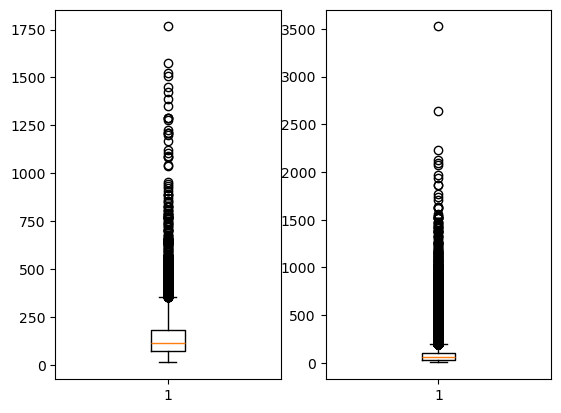

In [63]:
fig = plt.figure()

ax1 = fig.add_subplot(121)
ax1.boxplot(freq['Text_Length'])

ax1 = fig.add_subplot(122)
ax1.boxplot(nt_freq['Text_Length'])

Sentiment Analysis of Data

In [64]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [65]:
from textblob import TextBlob

In [67]:
data['Summary'][0]

'Good Quality Dog Food'

In [68]:
TextBlob('Good Quality Dog Food').sentiment.polarity

0.7

In [73]:
sample= data[0:5000]

In [74]:
polarity = []

for text in sample['Summary']:
    try:
        polarity.append(TextBlob(text).sentiment.polarity)
    except:
        polarity.append(0)

In [77]:
len(polarity)

5000

In [79]:
sample['Polarity'] = polarity

In [81]:
sample_negative = sample[sample['Polarity']<0]
sample_positive = sample[sample['Polarity']>0]

In [82]:
sample_negative.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Viwer_type,Text_Length,Polarity
16,17,B001GVISJM,A3KLWF6WQ5BNYO,Erica Neathery,0,0,2,2012-09-20,poor taste,I love eating them and they are good for watch...,Not Frequent,42,-0.400
26,27,B001GVISJM,A3RXAU2N8KV45G,lady21,0,1,1,2012-03-25,Nasty No flavor,"The candy is just red , No flavor . Just plan...",Not Frequent,22,-1.000
57,58,B004N5KULM,ASCNNAJU6SXF8,S. Beck,1,1,5,2012-05-05,How can you go wrong!,"It is chocolate, what can I say. Great variet...",Not Frequent,36,-0.625
61,62,B004N5KULM,A7ZK2A3VIW7X9,Peggy,0,2,5,2011-10-24,pretty expensive,"This bag of candy online is pretty expensive, ...",Not Frequent,30,-0.125
62,63,B001EO5TPM,A1E09XGZUR78C6,gary sturrock,2,2,1,2008-07-06,stale product.,Arrived in 6 days and were so stale i could no...,Not Frequent,17,-0.500


In [83]:
from collections import Counter

In [84]:
Counter(sample_negative['Summary']).most_common(10)

[('Awful', 6),
 ('Not Good', 4),
 ('Disappointing', 3),
 ('Disgusting', 3),
 ('Addicted', 3),
 ('Not good', 3),
 ('Not impressed', 3),
 ('disappointing', 2),
 ('Disappointed', 2),
 ('Disappointed!', 2)]

In [85]:
Counter(sample_positive['Summary']).most_common(10)

[('Delicious', 19),
 ('Delicious!', 18),
 ('Great', 13),
 ('Great product', 10),
 ('Excellent', 9),
 ('Love it!', 8),
 ('The Best', 8),
 ('Good', 6),
 ('Great Product', 6),
 ('delicious', 6)]